# 02 - Train Baseline Model

**Goal:** Train a single LightGBM model on 70/30 train/test split as a sanity check before walk-forward CV.

**Tasks:**
- Prepare features and labels (collapse 3-class to binary)
- Train separate models for LONG and SHORT directions
- Evaluate on hold-out 30%
- Check if ROC-AUC > 0.55 (minimum threshold for edge)
- Analyze feature importance
- Generate equity curve simulation

In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data_loader import load_datacollector_csv, get_data_splits
from src.labels import collapse_to_binary, print_label_summary
from src.features import get_feature_columns
from src.train import train_lightgbm, evaluate_model, get_feature_importance
from src.evaluate import calculate_trading_metrics, simulate_equity_curve, plot_equity_curve, plot_roc_curve

%matplotlib inline

## 1. Load Data

In [2]:
# Load and split data
csv_path = '../data/DataCollector_EURUSD_M5_20230101_220400.csv'
df = load_datacollector_csv(csv_path)

# Use only train/CV set (never touch held-out test here!)
train_cv, held_out_test, live_forward = get_data_splits(df)

print(f"Train/CV set: {len(train_cv):,} rows")
print(f"Date range: {train_cv['timestamp'].min()} to {train_cv['timestamp'].max()}")

Train/CV set: 204,105 rows
Date range: 2023-01-02 06:15:00 to 2025-09-30 00:00:00


## 2. Prepare Features and Labels - LONG Direction

In [3]:
# Get feature columns
features = get_feature_columns(train_cv)
print(f"Using {len(features)} features")

# Collapse to binary labels for LONG
df_long = collapse_to_binary(train_cv, direction="long", timeout_as="loss")

print(f"\nLONG label balance:")
print(df_long['label'].value_counts(normalize=True))

# 70/30 split
X = df_long[features]
y = df_long['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=False  # No shuffle for time series
)

print(f"\nTrain: {len(X_train):,} samples")
print(f"Test:  {len(X_test):,} samples")

Using 39 features

LONG label balance:
label
0    0.695706
1    0.304294
Name: proportion, dtype: float64

Train: 142,873 samples
Test:  61,232 samples


## 3. Train LONG Model

In [4]:
# Train model with validation set for early stopping
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, shuffle=False
)

print("Training LONG model...")
model_long = train_lightgbm(X_train_sub, y_train_sub, X_val, y_val)
print("Training complete!")

Training LONG model...
Training complete!


## 4. Evaluate LONG Model

In [5]:
# Evaluate on test set
metrics_long = evaluate_model(model_long, X_test, y_test, verbose=True)

# Check if meets minimum threshold
if metrics_long['roc_auc'] > 0.55:
    print("\n✓ Model meets minimum ROC-AUC threshold (>0.55)")
elif metrics_long['roc_auc'] > 0.52:
    print("\n⚠️  Model shows weak edge (0.52-0.55). Consider feature engineering.")
else:
    print("\n✗ Model shows no edge (≤0.52). Need to rethink features or approach.")


=== Model Evaluation ===
ROC-AUC:         0.5366
Accuracy:        0.6799
Predicted win%:  4.6%
Actual win%:     30.9%
Samples:         61,232

⚠️  Model shows weak edge (0.52-0.55). Consider feature engineering.



Top 20 features by importance:
             feature  importance  importance_pct
9   slope_sma_h1_200        1380        9.201227
18            atr_h1        1182        7.881051
7    dist_sma_h4_200        1020        6.800907
8   slope_sma_m5_200         780        5.200693
6    dist_sma_h1_200         745        4.967329
5   dist_sma_m30_200         729        4.860648
4   dist_sma_m15_200         695        4.633951
17           atr_m15         687        4.580611
33          hour_utc         621        4.140552
12           rsi_m30         542        3.613815
13            adx_m5         508        3.387118
16            atr_m5         495        3.300440
34               dow         470        3.133751
19   atr_ratio_m5_h1         465        3.100413
2    dist_sma_m5_200         462        3.080411
1    dist_sma_m5_100         455        3.033738
3    dist_sma_m5_275         423        2.820376
31   dist_swing_high         381        2.540339
32    dist_swing_low         359     

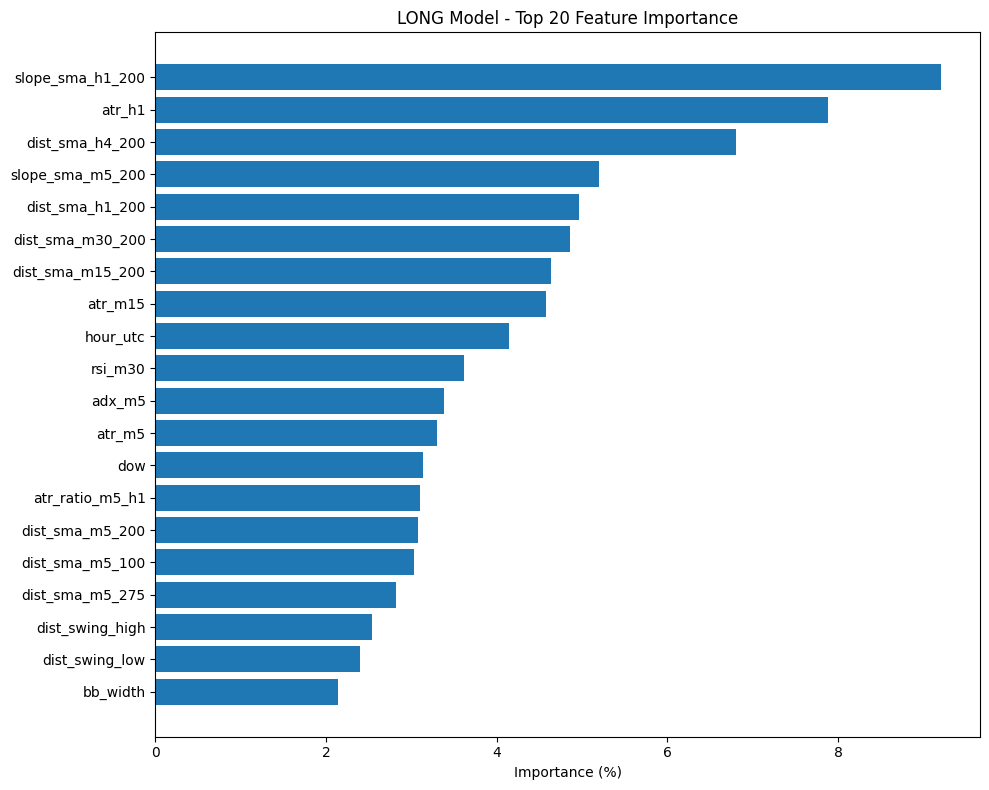

In [6]:
# Feature importance
importance_long = get_feature_importance(model_long, features, top_n=20)
print("\nTop 20 features by importance:")
print(importance_long)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_long['feature'], importance_long['importance_pct'])
plt.xlabel('Importance (%)')
plt.title('LONG Model - Top 20 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

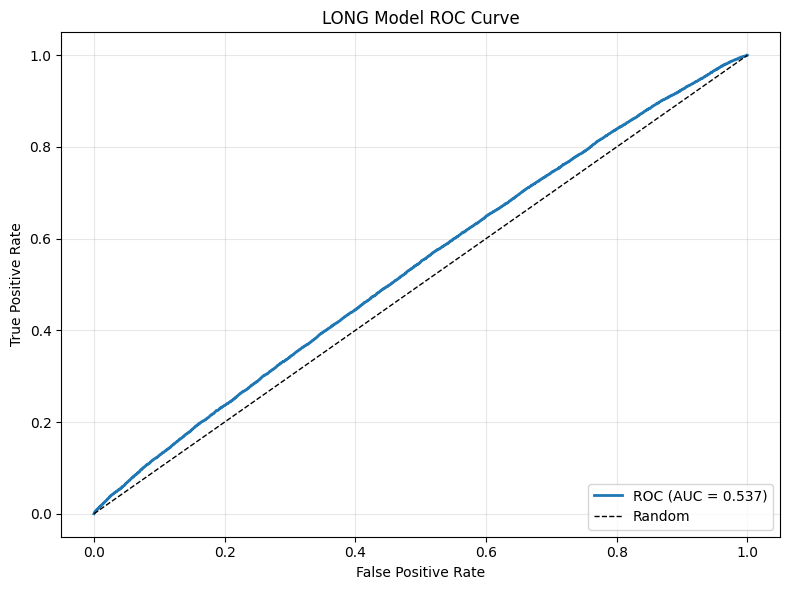

In [7]:
# ROC curve
y_pred_proba = model_long.predict_proba(X_test)[:, 1]
fig = plot_roc_curve(y_test, y_pred_proba, title="LONG Model ROC Curve")
plt.show()

## 5. Trading Simulation - LONG

In [8]:
# Calculate trading metrics at threshold = 0.5
y_pred = model_long.predict(X_test)
trading_metrics = calculate_trading_metrics(
    y_test.values, 
    y_pred, 
    risk_reward=2.0,  # 3.0 TP / 1.5 SL = 2.0 R:R
    commission_pips=0.0
)

print("\nTrading metrics (threshold=0.5):")
for key, val in trading_metrics.items():
    print(f"  {key:20s}: {val}")


Trading metrics (threshold=0.5):
  total_trades        : 61232
  wins                : 41630
  losses              : 19602
  win_rate            : 0.6798732688790176
  profit_factor       : 4.247525762677278
  expectancy_r        : 1.0396198066370526
  net_profit_r        : 63658.0
  gross_profit_r      : 83260.0
  gross_loss_r        : 19602.0


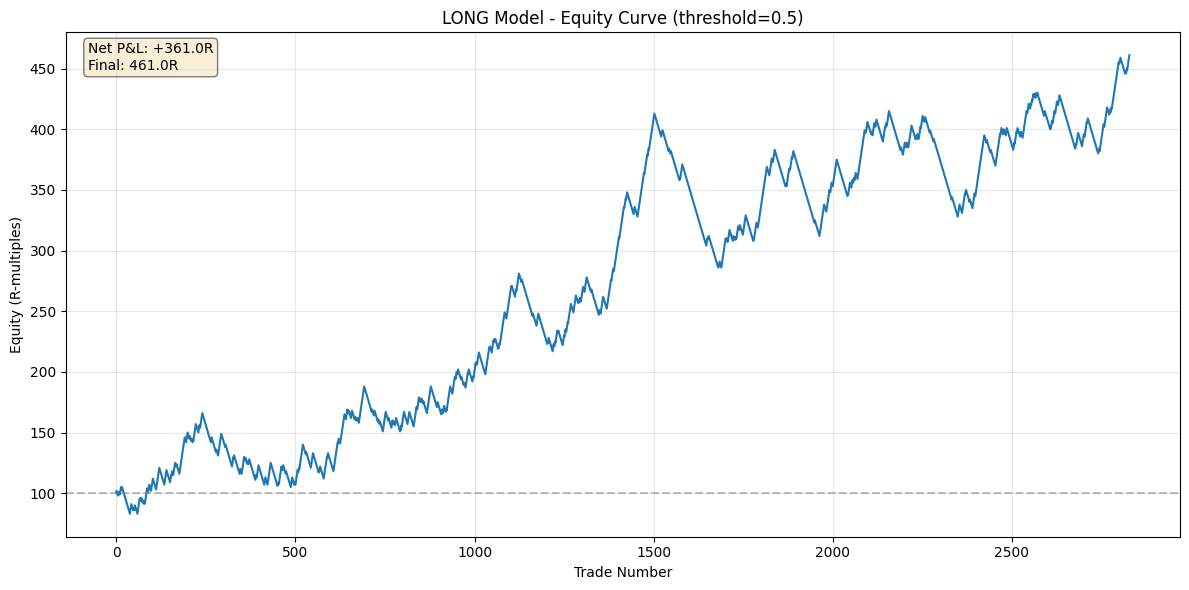

In [9]:
# Equity curve simulation
equity_df = simulate_equity_curve(
    y_test.values, 
    y_pred_proba, 
    threshold=0.5, 
    risk_reward=2.0,
    starting_capital_r=100.0
)

fig = plot_equity_curve(equity_df, title="LONG Model - Equity Curve (threshold=0.5)")
plt.show()

## 6. Train SHORT Model

Repeat the same process for SHORT direction.

In [10]:
# Collapse to binary labels for SHORT
df_short = collapse_to_binary(train_cv, direction="short", timeout_as="loss")

print(f"SHORT label balance:")
print(df_short['label'].value_counts(normalize=True))

X = df_short[features]
y = df_short['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=False
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, shuffle=False
)

print("\nTraining SHORT model...")
model_short = train_lightgbm(X_train_sub, y_train_sub, X_val, y_val)
print("Training complete!")

SHORT label balance:
label
0    0.69355
1    0.30645
Name: proportion, dtype: float64

Training SHORT model...
Training complete!


In [11]:
# Evaluate SHORT model
metrics_short = evaluate_model(model_short, X_test, y_test, verbose=True)

if metrics_short['roc_auc'] > 0.55:
    print("\n✓ Model meets minimum ROC-AUC threshold (>0.55)")
elif metrics_short['roc_auc'] > 0.52:
    print("\n⚠️  Model shows weak edge (0.52-0.55). Consider feature engineering.")
else:
    print("\n✗ Model shows no edge (≤0.52). Need to rethink features or approach.")


=== Model Evaluation ===
ROC-AUC:         0.5462
Accuracy:        0.6875
Predicted win%:  3.8%
Actual win%:     30.3%
Samples:         61,232

⚠️  Model shows weak edge (0.52-0.55). Consider feature engineering.


In [12]:
  # === Try More Aggressive Hyperparameters ===
  print("\n" + "="*70)
  print("Attempting Hyperparameter Tuning")
  print("="*70)

  params_tuned = {
      'objective': 'binary',
      'metric': 'auc',
      'boosting_type': 'gbdt',
      'num_leaves': 63,
      'max_depth': 9,
      'learning_rate': 0.03,
      'n_estimators': 1000,
      'min_child_samples': 100,
      'subsample': 0.8,
      'colsample_bytree': 0.7,
      'reg_alpha': 1.0,
      'reg_lambda': 1.0,
      'random_state': 42,
      'verbose': -1
  }

  # Retrain LONG model with tuned params
  print("\nRetraining LONG model with tuned hyperparameters...")
  model_long_tuned = train_lightgbm(X_train_sub, y_train_sub, X_val, y_val, params=params_tuned)

  print("\n--- Tuned LONG Model ---")
  metrics_long_tuned = evaluate_model(model_long_tuned, X_test, y_test, verbose=True)

  if metrics_long_tuned['roc_auc'] > 0.55:
      print("\nSUCCESS! Model exceeds 0.55 ROC-AUC threshold")
  elif metrics_long_tuned['roc_auc'] > 0.52:
      print(f"\nStill weak edge ({metrics_long_tuned['roc_auc']:.4f}), but improved from {metrics_long['roc_auc']:.4f}")

  # Retrain SHORT model
  print("\n\nRetraining SHORT model with tuned hyperparameters...")
  X = df_short[features]
  y = df_short['label']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)
  X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, shuffle=False)

  model_short_tuned = train_lightgbm(X_train_sub, y_train_sub, X_val, y_val, params=params_tuned)

  print("\n--- Tuned SHORT Model ---")
  metrics_short_tuned = evaluate_model(model_short_tuned, X_test, y_test, verbose=True)

  if metrics_short_tuned['roc_auc'] > 0.55:
      print("\nSUCCESS! Model exceeds 0.55 ROC-AUC threshold")
  elif metrics_short_tuned['roc_auc'] > 0.52:
      print(f"\nStill weak edge ({metrics_short_tuned['roc_auc']:.4f}), but improved from {metrics_short['roc_auc']:.4f}")

  # Summary
  print("\n" + "="*70)
  print("Tuning Summary")
  print("="*70)
  print(f"LONG:  {metrics_long['roc_auc']:.4f} -> {metrics_long_tuned['roc_auc']:.4f} ({metrics_long_tuned['roc_auc']-metrics_long['roc_auc']:+.4f})")
  print(f"SHORT: {metrics_short['roc_auc']:.4f} -> {metrics_short_tuned['roc_auc']:.4f} ({metrics_short_tuned['roc_auc']-metrics_short['roc_auc']:+.4f})")


Attempting Hyperparameter Tuning

Retraining LONG model with tuned hyperparameters...

--- Tuned LONG Model ---

=== Model Evaluation ===
ROC-AUC:         0.5461
Accuracy:        0.6771
Predicted win%:  6.9%
Actual win%:     30.3%
Samples:         61,232

Still weak edge (0.5461), but improved from 0.5366


Retraining SHORT model with tuned hyperparameters...

--- Tuned SHORT Model ---

=== Model Evaluation ===
ROC-AUC:         0.5461
Accuracy:        0.6771
Predicted win%:  6.9%
Actual win%:     30.3%
Samples:         61,232

Still weak edge (0.5461), but improved from 0.5462

Tuning Summary
LONG:  0.5366 -> 0.5461 (+0.0095)
SHORT: 0.5462 -> 0.5461 (-0.0001)


## 7. Summary

**LONG Model:**
- ROC-AUC: [fill from output]
- Win rate: [fill from output]
- Expected value: [fill from output]

**SHORT Model:**
- ROC-AUC: [fill from output]
- Win rate: [fill from output]
- Expected value: [fill from output]

**Next step:** If both models show ROC-AUC > 0.55, proceed to walk-forward CV in notebook 03.